# Streaming

- [docs](https://docs.langchain.com/oss/python/langgraph/streaming)

## Get Started

### Basic Usage

- Langgraph graphs expose the `stream` (sync) `astream` (async) methods to yield streamed outputs as iterators. Pass one or more [stream modes](https://docs.langchain.com/oss/python/langgraph/streaming#stream-modes) to control data you receive

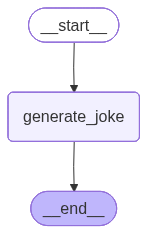

In [1]:
# Full example

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.config import get_stream_writer
from IPython.display import Image, display

class State(TypedDict):
    topic: str
    joke: str

def generate_joke(state: State):
    writer = get_stream_writer()
    writer({"status": "thinking of joke..."})
    return {"joke": f"Why did the {state['topic']} go to school? To get a sundae education!"}

graph = (
    StateGraph(State)
    .add_node(generate_joke)
    .add_edge(START, "generate_joke")
    .add_edge("generate_joke", END)
    .compile()
)

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode=["updates", "custom"],
    version="v2"
):
    if chunk["type"] == "updates":
        for node_name, state in chunk["data"].items():
            print(f"Node `{node_name}` updated: {state}")
    elif chunk["type"] == "custom":
        print(f"Status: {chunk['data']['status']}")

Status: thinking of joke...
Node `generate_joke` updated: {'joke': 'Why did the ice cream go to school? To get a sundae education!'}


In [4]:
help(get_stream_writer)

Help on function get_stream_writer in module langgraph.config:

get_stream_writer() -> collections.abc.Callable[[typing.Any], None]
    Access LangGraph [`StreamWriter`][langgraph.types.StreamWriter] from inside a graph node or entrypoint task at runtime.

    Can be called from inside any [`StateGraph`][langgraph.graph.StateGraph] node or
    functional API [`task`][langgraph.func.task].

    !!! warning "Async with Python < 3.11"

        If you are using Python < 3.11 and are running LangGraph asynchronously,
        `get_stream_writer()` won't work since it uses [`contextvar`](https://docs.python.org/3/library/contextvars.html) propagation (only available in [Python >= 3.11](https://docs.python.org/3/library/asyncio-task.html#asyncio.create_task)).

    Example: Using with `StateGraph`
        ```python
        from typing_extensions import TypedDict
        from langgraph.graph import StateGraph, START
        from langgraph.config import get_stream_writer


        class State(Ty

Lets run that again to better understand the what constitues a chunk

In [5]:
for chunk in graph.stream({"topic":"Ice Cream"}, stream_mode=["updates", "custom"], version="v2"):
    print(chunk)

{'type': 'custom', 'ns': (), 'data': {'status': 'thinking of joke...'}}
{'type': 'updates', 'ns': (), 'data': {'generate_joke': {'joke': 'Why did the Ice Cream go to school? To get a sundae education!'}}}


### Stream output format (v2)

- Pass `version="v2"` to `stream()` or `astream()` to get unified output format. 
- Every chunk is a `StreamPart` dict with a consistent Shape

```
{
    "type": "values" | "updates" | "messages" | "custom" | "checkpoints" | "tasks" | "debug",
    "ns": (),           # namespace tuple, populated for subgraph events
    "data": ...,        # the actual payload (type varies by stream mode)
}
```

Each stream mode has corresponding `TypedDict` containing:
- [ValuesStreamPart](https://reference.langchain.com/python/langgraph/types/ValuesStreamPart)
- [UpdatesStreamPart](https://reference.langchain.com/python/langgraph/types/UpdatesStreamPart)
- [MessagesStreamPart](https://reference.langchain.com/python/langgraph/types/MessagesStreamPart)
- [CustomStreamPart](https://reference.langchain.com/python/langgraph/types/CustomStreamPart)
- [CheckpointStreamPart](https://reference.langchain.com/python/langgraph/types/CheckpointStreamPart)
- [TasksStreamPart](https://reference.langchain.com/python/langgraph/types/TasksStreamPart)
- [DebugStreamPart](https://reference.langchain.com/python/langgraph/types/DebugStreamPart)

We can import these types from `langgraph.types`


With v1 (default), the output format changes based on your streaming options (single mode returns raw data, multiple modes return (mode, data) tuples, subgraphs return (namespace, data) tuples). With v2, the format is always the same:

In [ ]:
# v2

for chunk in graph.stream({"topic":"Ice cream"}, stream_mode="updates", version="v2"):
    print(f"Streaming Mode: {chunk['type']}")
    print(f"Namespace: {chunk['ns']}")
    print(f"Data: {chunk['data']}") # data section contains both the node_name and the state.

Streaming Mode: updates
Namespace: ()
Data: {'generate_joke': {'joke': 'Why did the Ice cream go to school? To get a sundae education!'}}


In [ ]:
# v1 (default)

for chunk in graph.stream({"topic":"Ice cream"}, stream_mode="updates"):
    print(chunk) # {"node_name": {"key": "value"}}

{'generate_joke': {'joke': 'Why did the Ice cream go to school? To get a sundae education!'}}


The v2 format also enables type narrowing, which means you can filter chunks by `chunk["type"]` and get the correct payload type. Each branch narrows `part["data"]` to the specific type for that mode:

In [11]:
for part in graph.stream(
    {"topic": "ice cream"},
    stream_mode=["values", "updates", "messages", "custom"],
    version="v2",
):
    if part["type"] == "values":
        # ValuesStreamPart — full state snapshot after each step
        print(f"State: topic={part['data']['topic']}")
    elif part["type"] == "updates":
        # UpdatesStreamPart — only the changed keys from each node
        for node_name, state in part["data"].items():
            print(f"Node `{node_name}` updated: {state}")
    elif part["type"] == "messages":
        # MessagesStreamPart — (message_chunk, metadata) from LLM calls
        msg, metadata = part["data"]
        print(msg.content, end="", flush=True)
    elif part["type"] == "custom":
        # CustomStreamPart — arbitrary data from get_stream_writer()
        print(f"Progress: {part['data'].get('progress','')}%")

State: topic=ice cream
Progress: %
Node `generate_joke` updated: {'joke': 'Why did the ice cream go to school? To get a sundae education!'}
State: topic=ice cream


### Stream Modes:

- [Documentation link](https://docs.langchain.com/oss/python/langgraph/streaming#stream-modes)


### Graph State

Use the stream modes `updates` and `values` to stream the state of the graph as it executes.
- `updates` streams the updates to the state after each step of the graph.
- `values` streams the full value of the state after each step of the graph.

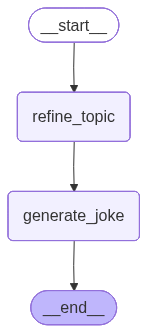

In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
  topic: str
  joke: str


def refine_topic(state: State):
    return {"topic": state["topic"] + " and cats"}


def generate_joke(state: State):
    return {"joke": f"This is a joke about {state['topic']}"}

graph = (
  StateGraph(State)
  .add_node(refine_topic)
  .add_node(generate_joke)
  .add_edge(START, "refine_topic")
  .add_edge("refine_topic", "generate_joke")
  .add_edge("generate_joke", END)
  .compile()
)

display(Image(graph.get_graph().draw_mermaid_png()))

#### Updates

In [13]:
for chunk in graph.stream({"topic":"ice cream"}, stream_mode="updates", version="v2"):
    if chunk["type"] == "updates":
        for node_name, state in chunk["data"].items():
            print(f"Node: `{node_name}` updated : {state}")

Node: `refine_topic` updated : {'topic': 'ice cream and cats'}
Node: `generate_joke` updated : {'joke': 'This is a joke about ice cream and cats'}


#### Values

In [ ]:
for chunk in graph.stream({"topic":"ice cream"}, stream_mode="values", version="v2"):
    if chunk["type"] == "values":
        print(f"Complete State at each node: {chunk['data']}")
        # print(f"Topic: {chunk['data']['topic']}, joke: {chunk['data']['joke']}")

Complete State at each node: {'topic': 'ice cream'}
Complete State at each node: {'topic': 'ice cream and cats'}
Complete State at each node: {'topic': 'ice cream and cats', 'joke': 'This is a joke about ice cream and cats'}


### LLM Tokens

- Use the `messages` streaming mode to stream LLM output tokens.
- This can be done from any part of our graph, including nodes, tools, subgraphs, or tasks

The streamed output from `messages` mode is a tuple `(message_chunk, metadata)` where:
- `mesasges_chunk`: the token or message segment from the LLM.
- `metadata`: a dict containing details about the graph node and LLM invocation

In [18]:
from dataclasses import dataclass

from langchain.chat_models import init_chat_model

model_name, model_provider=("gpt-oss", "ollama")

model = init_chat_model(model=model_name, model_provider=model_provider)

d:\workspace\AI\langchain-academy\langgraph-foundation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [20]:
response = model.invoke("Hello, I am najeeb and i wanted to see if i can run `init_chat_model` with local ollama models")

response.pretty_print()

================================== Ai Message ==================================

**TL;DR**  
`init_chat_model` (the helper that ships with **llama‑cpp‑python**) is *not* able to talk to an Ollama server. It only knows how to load a model that lives on disk in Llama‑cpp format (i.e. a `.bin`/`.gguf` file that you downloaded or compiled yourself).  

If you want to use a model that is running inside Ollama, you need to call the **Ollama HTTP API** (or use a wrapper that does that for you, e.g. LangChain’s `Ollama` or `OllamaChat` classes).  

Below you’ll find two ways to get the same “chat‑style” experience:

| Goal | What you need | Typical code | Notes |
|------|---------------|--------------|-------|
| **Run a local Llama‑cpp model** | Model file (`.gguf`/`.bin`), `llama-cpp-python` | `from llama_cpp import Llama; llm = Llama(model_path="models/ggml-model.bin")` | Use `init_chat_model` only if you’re using the older `llama_cpp` package that ships with it. |
| **Run a model that is h

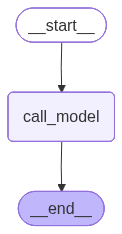

In [25]:
from langchain_core.messages import HumanMessage

@dataclass
class MyState:
    topic: str
    joke: str = ""

model = init_chat_model(model=model_name, model_provider=model_provider)

def call_model(state: MyState):
    """Call the LLM to generate a joke about a topic"""
    # NOTE: that message events are emitted even when the LLM is run using `.invoke` rather than `.stream`
    model_response = model.invoke(
        [HumanMessage(content=f"Generate joke about {state.topic}")]
    )
    return {"joke": model_response.content}

graph = (
    StateGraph(MyState)
    .add_node(call_model)
    .add_edge(START, "call_model")
    .compile()
)

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
# The "messages" stream mode streams LLM tokens with metadata
# Use version="v2" for a unified StreamPart format

for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="messages",
    version="v2"
):
    if chunk["type"] == "messages":
        message_chunk, metadata = chunk["data"]
        if message_chunk.content:
            print(message_chunk.content, end="|", flush=True)

Why| did| the| ice|‑|cream| get| promoted| at| the| office|?|  

|Because| it| always| knew| how| to| *|ch|urn|*| out| great| ideas|!|

#### Filter By LLM Invocation 

- use tags to filter 
- Follow [docs](https://docs.langchain.com/oss/python/langgraph/streaming#filter-by-llm-invocation)

In [30]:
from typing import TypedDict


joke_model  = init_chat_model(model="gpt-oss", model_provider = model_provider, tags=["joke"])
poem_model  = init_chat_model(model="qwen3.5", model_provider = model_provider, tags=["poem"])

class State(TypedDict):
    topic: str
    joke: str
    poem: str

async def call_model(state, config):
    topic = state["topic"]
    print('Writing Joke...')
    joke_response = await joke_model.ainvoke(
            [{"role": "user", "content": f"Write a joke about {topic}"}],
            config,
    )

    print("\n\nWriting poem...")
    poem_response = await poem_model.ainvoke(
        [{"role": "user", "content": f"Write a short poem about {topic}"}],
        config,
    )
    return {"joke": joke_response.content, "poem": poem_response.content}


graph = (
      StateGraph(State)
      .add_node(call_model)
      .add_edge(START, "call_model")
      .compile()
)

# The stream_mode is set to "messages" to stream LLM tokens
# The metadata contains information about the LLM invocation, including the tags
async for chunk in graph.astream(
      {"topic": "cats"},
      stream_mode="messages",
      version="v2",
):
    if chunk["type"] == "messages":
        msg, metadata = chunk["data"]
        if metadata["tags"] == ["joke"]:
            print(msg.content, end="|", flush=True)



Writing Joke...
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Why| did| the| cat| bring| a| ladder| to| the| bar|?

|Because| it| heard| the| drinks| were| on| the| house|!| 🐱|🍹|||

Writing poem...


### Custom Data

- send custom user defined data from Langgraph node or tool.
  - use `get_stream_writer` to access the stream writer and emit custom data.
  - set `stream_mode="custom"`
  - multiple modes can be combined 
- [Docs](https://docs.langchain.com/oss/python/langgraph/streaming#custom-data)

In [31]:
from langgraph.config import get_stream_writer

class State(TypedDict):
    question: str
    answer: str

def node(state):
    writer = get_stream_writer()
    writer({"custom_key": "Generating custom data inside node."})
    return {"answer": "Some data"}

graph = (
    StateGraph(State)
    .add_node(node)
    .add_edge(START, "node")
    .compile()
)

inputs = {"query": "example"}

for chunk in graph.stream(inputs, stream_mode="custom", version="v2"):
    if chunk["type"] == "custom":
        print(f"Custom event: {chunk['data']['custom_key']}")

Custom event: Generating custom data inside node.


### Subgraph Outputs

To include outputs from [subgraphs](https://docs.langchain.com/oss/python/langgraph/use-subgraphs) in the streamed outputs, you can set subgraphs=True in the .stream() method of the parent graph. This will stream outputs from both the parent graph and any subgraphs.

The outputs will be streamed as tuples (namespace, data), where namespace is a tuple with the path to the node where a subgraph is invoked, e.g. ("parent_node:<task_id>", "child_node:<task_id>").

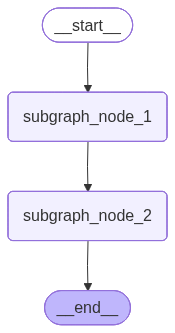

In [32]:
# Define subgraph
class SubgraphState(TypedDict):
    foo: str  # note that this key is shared with the parent graph state
    bar: str

def subgraph_node_1(state: SubgraphState):
    return {"bar": "bar"}

def subgraph_node_2(state: SubgraphState):
    return {"foo": state["foo"] + state["bar"]}

subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()

display(Image(subgraph.get_graph().draw_mermaid_png()))

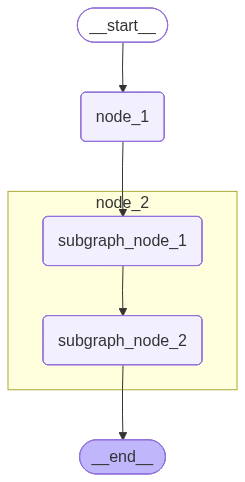

In [34]:
# Define parent graph
class ParentState(TypedDict):
    foo: str

def node_1(state: ParentState):
    return {"foo": f"Hi! {state['foo']}"}

graph = (
    StateGraph(ParentState)
    .add_node(node_1)
    .add_node("node_2", subgraph)
    .add_edge(START, "node_1")
    .add_edge("node_1", "node_2")
    .compile()
)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [36]:
for chunk in graph.stream(
    {"foo": "foo"},
    stream_mode="updates",
    subgraph=True,
    version="v2"
):
    if chunk["type"]=="updates":
        if chunk["ns"]:
            print(f"Subgraph::: {chunk['ns']}: {chunk['data']}")
        else:
            print(f"Root::: {chunk['data']}")

Root::: {'node_1': {'foo': 'Hi! foo'}}
Root::: {'node_2': {'foo': 'Hi! foobar'}}


##### Notice the Subtle type: `subgraph` vs `subgraphs`.

- if `subgraphs` is not set to `True`, then subgraph will not be able to stream the events

In [37]:
for chunk in graph.stream(
    {"foo": "foo"},
    stream_mode="updates",
    subgraphs=True,
    version="v2"
):
    if chunk["type"]=="updates":
        if chunk["ns"]:
            print(f"Subgraph::: {chunk['ns']}: {chunk['data']}")
        else:
            print(f"Root::: {chunk['data']}")

Root::: {'node_1': {'foo': 'Hi! foo'}}
Subgraph::: ('node_2:ae5a6d9b-0543-ec87-efd2-50c99792734e',): {'subgraph_node_1': {'bar': 'bar'}}
Subgraph::: ('node_2:ae5a6d9b-0543-ec87-efd2-50c99792734e',): {'subgraph_node_2': {'foo': 'Hi! foobar'}}
Root::: {'node_2': {'foo': 'Hi! foobar'}}
